## Notebook 3: Classifying Stars, Galaxies, and Quasars

**Audience:** First-year PhD students in Astrophysics  
**Theme:** Turning survey observables into probabilistic object labels

### Astrophysics context

Modern sky surveys detect enormous numbers of sources.
A central pipeline task is assigning likely classes such as:

- star
- galaxy
- quasar (QSO)

Spectroscopic labels are usually the most reliable labels because emission/absorption lines reveal the physical nature of the source.

However, spectroscopy is expensive in telescope time.

Imaging surveys instead rely on:

- broadband colours
- morphology (point-like vs extended)
- statistical learning methods

This notebook mirrors a real survey workflow:

> use a limited spectroscopic sample to train a classifier,  
> then assign probabilistic labels to the much larger photometric sample.

### Scientific question

> Given photometric measurements, what is this source likely to be?

This is a supervised classification problem.

### What you will learn

- How colours separate source populations
- Binary and multiclass classification
- Logistic Regression as probabilistic fitting
- Random Forest classification
- Confusion matrices
- ROC curves
- Precision–Recall curves
- Calibrated probabilities
- Class imbalance and survey bias
- Why probability quality often matters more than raw accuracy

### Core idea

> Classification = decision boundaries in feature space  
> + trustworthy probabilities



## Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator, calibration_curve

from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    mean_squared_error, 
    r2_score,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    log_loss, 
    balanced_accuracy_score,
    silhouette_score
)



# Set Random Seed and Plotting Style

This step initializes reproducibility and configures the default visualization settings.

A fixed random seed is defined to ensure that any random processes (such as sampling or model initialization) produce consistent results across runs. A NumPy random generator is created using this seed.

The plotting style is also set to a predefined Matplotlib theme that improves readability and accessibility. Default figure size and font size are adjusted to make all plots clearer and more consistent throughout the notebook.

These settings ensure that results are both reproducible and visually consistent across all visualizations.

In [2]:
SEED = 42
rng = np.random.default_rng(SEED)

plt.style.use("tableau-colorblind10")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12


# Load Data

In this step, we load the SDSS dataset from a CSV file into a Pandas DataFrame.

- The dataset is read using `pandas.read_csv()`
- We specify the file path to the dataset (`SDSS_DR18.csv`)
- After loading, we print the shape of the dataset to understand:
  - Number of rows (samples)
  - Number of columns (features)

### Code Summary:
- Loads the dataset into memory
- Checks dataset dimensions for a quick sanity check



In [3]:
# Load Data
# Update the path to your dataset file

file_path = "SDSS_DR18.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)


Shape: (100000, 43)


In [4]:
print(df.head())


          objid     specobjid          ra       dec         u         g  \
0  1.240000e+18  3.240000e+17  184.950869  0.733068  18.87062  17.59612   
1  1.240000e+18  3.250000e+17  185.729201  0.679704  19.59560  19.92153   
2  1.240000e+18  3.240000e+17  185.687690  0.823480  19.26421  17.87891   
3  1.240000e+18  2.880000e+18  185.677904  0.768362  19.49739  17.96166   
4  1.240000e+18  2.880000e+18  185.814763  0.776940  18.31519  16.83033   

          r         i         z  run  ...  psfMag_g  psfMag_i  psfMag_z  \
0  17.11245  16.83899  16.70908  756  ...  19.96352  19.25145  19.05230   
1  20.34448  20.66213  20.59599  756  ...  19.92417  20.65535  20.57387   
2  17.09593  16.65159  16.35329  756  ...  19.33645  18.16669  17.78844   
3  17.41269  17.20545  17.11567  756  ...  17.96176  17.21564  17.12367   
4  16.26352  16.06320  15.97527  756  ...  16.85104  16.08275  15.98694   

    expAB_u   expAB_g   expAB_r   expAB_i   expAB_z  redshift   class  
0  0.479021  0.518483  0.5

In [5]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   objid        100000 non-null  float64
 1   specobjid    100000 non-null  float64
 2   ra           100000 non-null  float64
 3   dec          100000 non-null  float64
 4   u            100000 non-null  float64
 5   g            100000 non-null  float64
 6   r            100000 non-null  float64
 7   i            100000 non-null  float64
 8   z            100000 non-null  float64
 9   run          100000 non-null  int64  
 10  rerun        100000 non-null  int64  
 11  camcol       100000 non-null  int64  
 12  field        100000 non-null  int64  
 13  plate        100000 non-null  int64  
 14  mjd          100000 non-null  int64  
 15  fiberid      100000 non-null  int64  
 16  petroRad_u   100000 non-null  float64
 17  petroRad_g   100000 non-null  float64
 18  petroRad_i   100000 non-n

# Basic Data Cleaning

This step checks for missing values in the dataset and performs a simple cleaning operation.

First, the number of missing values in each column is computed to understand the completeness of the dataset. 

This helps identify whether any features contain incomplete data that could affect model performance.

Next, all rows containing missing values are removed. 

This is a simple baseline approach to ensure the dataset is fully complete before training models, avoiding issues caused by NaN values during computation or model fitting.

In [6]:
# Check missing values
print("Missing values per column:\n", df.isnull().sum())
df_clean = df.dropna(axis=0)


Missing values per column:
 objid          0
specobjid      0
ra             0
dec            0
u              0
g              0
r              0
i              0
z              0
run            0
rerun          0
camcol         0
field          0
plate          0
mjd            0
fiberid        0
petroRad_u     0
petroRad_g     0
petroRad_i     0
petroRad_r     0
petroRad_z     0
petroFlux_u    0
petroFlux_g    0
petroFlux_i    0
petroFlux_r    0
petroFlux_z    0
petroR50_u     0
petroR50_g     0
petroR50_i     0
petroR50_r     0
petroR50_z     0
psfMag_u       0
psfMag_r       0
psfMag_g       0
psfMag_i       0
psfMag_z       0
expAB_u        0
expAB_g        0
expAB_r        0
expAB_i        0
expAB_z        0
redshift       0
class          0
dtype: int64


# Physical Data Cleaning and Outlier Filtering

This step applies physically motivated constraints to remove invalid or non-physical observations from the dataset.

Magnitude values are filtered to keep only objects within a realistic observational range, ensuring that extreme or corrupted measurements are excluded. 

Additional constraints are applied to remove entries with invalid or non-positive Petrosian radius values.

After filtering, the dataset is further refined by clipping extreme color index values. 

This stabilizes the feature distributions and reduces the impact of outliers that could distort model training.

Finally, the number of removed samples is reported to quantify the effect of the cleaning process.

In [7]:
# 1. Define physical constraints

filters = (
    # 1. Avoid saturation and heavy noise
    (df_clean["r"].between(14.0, 22.0)) & 
    
    # 2. Ensure all bands have valid, non-zero detections
    # (Magnitudes of 0 or 99 are often 'null' flags in catalogs)
    (df_clean["u"] > 10) & (df_clean["u"] < 25) &
    (df_clean["g"] > 10) & (df_clean["g"] < 25) &
    (df_clean["i"] > 10) & (df_clean["i"] < 25) &
    (df_clean["z"] > 10) & (df_clean["z"] < 25) &
    (df_clean["petroRad_r"] > 0)
)

# 2. Apply filters
df_model = df_clean[filters].copy()

print(f"Removed {len(df_clean) - len(df_model)} non-physical objects.")



Removed 866 non-physical objects.


# Feature Engineering

This step creates new informative features from the raw SDSS measurements to improve model performance.

###### Colors
Color indices are computed from magnitude differences between adjacent bands. 

These capture the spectral properties of objects and are highly effective for distinguishing between stars, galaxies, and quasars.

###### Shapes

Shape-related statistics are derived from the `expAB` parameters by computing their mean and standard deviation across all bands. 

These features describe the overall symmetry and variation in object shapes.

###### Sizes

Size-based ratios are created using Petrosian radii and half-light radii. 

These ratios help quantify how extended an object is, which is useful for separating point sources (stars) from extended sources (galaxies).

###### PSF morphology

Additional morphology features are constructed by combining PSF magnitudes with flux measurements to approximate structural differences in light distribution.

###### Aggregated statistics 
Finally, aggregated statistics such as mean Petrosian radius and mean half-light radius are computed to summarize object size across all bands.

In astronomy, we perform **Star-Galaxy Separation**. 

By comparing two different ways of measuring light from the same object, you can determine if that object is a "point source" (a star) or "extended" (a galaxy).

Here is the breakdown of why this specific feature is so powerful for your stellar temperature model:

### 1. Point Source vs. Extended Source
*   **psfMag (Point Spread Function Magnitude):** This assumes the object is a single point of light. It fits a model of the telescope's optics to the object.
*   **petroFlux/petroMag (Petrosian Flux):** This is designed to capture the "total" light of an object, regardless of how much it spreads out (like a fuzzy galaxy).

**The Logic:**
*   **For a Star:** The PSF model and the Petrosian model should agree. The difference `mag - instrumental_mag` will be near a constant (often zero or a small offset).
*   **For a Galaxy:** The Petrosian flux will be much larger than the PSF flux because a galaxy has "wings" of light that the PSF model ignores. This creates a large numerical difference.

### 2. Cleaning the "Contamination"
Your model is specifically trying to infer **Stellar** temperatures. If a small, compact galaxy or a Quasar (which looks like a star) accidentally stays in your dataset, it will have colors that don't follow the "Stellar Locus." 

By calculating `psf_shape`, you are giving the Machine Learning model a way to "see" the morphology of the object:
*   If `psf_shape` is small $\rightarrow$ It's a star $\rightarrow$ Trust the color-temperature relation.
*   If `psf_shape` is large $\rightarrow$ It's a galaxy $\rightarrow$ The color-temperature relation is likely invalid for this object.

### 3. Reddening and Density Diagnostics
In very crowded fields or regions with high interstellar dust (extinction), the PSF can become slightly distorted. Including these features helps the model correct for systematic errors in the photometry that are tied to how the light was measured, rather than the physics of the star itself.

### The Math in your Code
$$ \text{psf_shape} = \text{psfMag} - (-2.5 \log_{10}(\text{flux})) $$

The term `-2.5 * np.log10(flux)` is simply converting the raw Petrosian flux into a magnitude scale. 

By subtracting one from the other, you are essentially calculating:

$$\Delta m = m_{\text{psf}} - m_{\text{petrosian}}$$

In SDSS-like data, a common rule of thumb is that if $|m_{\text{psf}} - m_{\text{model}}| < 0.145$, the object is a star. 


In [8]:
from sklearn.base import BaseEstimator, TransformerMixin

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns if hasattr(X, "columns") else None
        return self

    def transform(self, X):
        X = X.copy()

        # Colors
        X["u_g"] = X["u"] - X["g"]
        X["g_r"] = X["g"] - X["r"]
        X["r_i"] = X["r"] - X["i"]
        X["i_z"] = X["i"] - X["z"]

        # Shapes
        shape_cols = ["expAB_u", "expAB_g", "expAB_r", "expAB_i", "expAB_z"]
        X["expAB_mean"] = X[shape_cols].mean(axis=1)
        X["expAB_std"] = X[shape_cols].std(axis=1)

        # Sizes
        X["petro_size_ratio_r"] = X["petroR50_r"] / (X["petroRad_r"] + 1e-6)
        X["petro_size_ratio_g"] = X["petroR50_g"] / (X["petroRad_g"] + 1e-6)
        X["petro_size_ratio_i"] = X["petroR50_i"] / (X["petroRad_i"] + 1e-6)

        # PSF morphology
        def psf_shape(mag, flux):
            return mag - (-2.5 * np.log10(np.clip(flux, 1e-10, None)))

        X["psf_shape_r"] = psf_shape(X["psfMag_r"], X["petroFlux_r"])
        X["psf_shape_g"] = psf_shape(X["psfMag_g"], X["petroFlux_g"])
        X["psf_shape_i"] = psf_shape(X["psfMag_i"], X["petroFlux_i"])

        # Aggregates
        rad_cols = ["petroRad_u","petroRad_g","petroRad_r","petroRad_i","petroRad_z"]
        r50_cols = ["petroR50_u","petroR50_g","petroR50_r","petroR50_i","petroR50_z"]

        X["petroRad_mean"] = X[rad_cols].mean(axis=1)
        X["petroR50_mean"] = X[r50_cols].mean(axis=1)

        return X

    def get_feature_names_out(self, input_features=None):
        """
        Makes PCA / ColumnTransformer / SHAP compatible
        """

        base = list(input_features) if input_features is not None else []

        engineered = [
            "u_g", "g_r", "r_i", "i_z",
            "expAB_mean", "expAB_std",
            "petro_size_ratio_r", "petro_size_ratio_g", "petro_size_ratio_i",
            "psf_shape_r", "psf_shape_g", "psf_shape_i",
            "petroRad_mean", "petroR50_mean"
        ]

        return np.array(base + engineered)

In [9]:
# Colors
#df_model["u_g"] = df_model["u"] - df_model["g"]
#df_model["g_r"] = df_model["g"] - df_model["r"]
#df_model["r_i"] = df_model["r"] - df_model["i"]
#df_model["i_z"] = df_model["i"] - df_model["z"]

# Shapes
#df_model["expAB_mean"] = df_model[[
#    "expAB_u", "expAB_g", "expAB_r", "expAB_i", "expAB_z"
#]].mean(axis=1)

#df_model["expAB_std"] = df_model[[
#    "expAB_u", "expAB_g", "expAB_r", "expAB_i", "expAB_z"
#]].std(axis=1)

# Sizes
#df_model["petro_size_ratio_r"] = df_model["petroR50_r"] / (df_model["petroRad_r"] + 1e-6)
#df_model["petro_size_ratio_g"] = df_model["petroR50_g"] / (df_model["petroRad_g"] + 1e-6)
#df_model["petro_size_ratio_i"] = df_model["petroR50_i"] / (df_model["petroRad_i"] + 1e-6)

# PSF morphology
# This is a proxy feature and may include calibration-dependent effects.
#df_model["psf_shape_r"] = df_model["psfMag_r"] - (-2.5 * np.log10(df_model["petroFlux_r"].clip(lower=1e-10)))
#df_model["psf_shape_g"] = df_model["psfMag_g"] - (-2.5 * np.log10(df_model["petroFlux_g"].clip(lower=1e-10)))
#df_model["psf_shape_i"] = df_model["psfMag_i"] - (-2.5 * np.log10(df_model["petroFlux_i"].clip(lower=1e-10)))

# Aggregated statistics 
#df_model["petroRad_mean"] = df_model[
#    ["petroRad_u","petroRad_g","petroRad_r","petroRad_i","petroRad_z"]
#].mean(axis=1)

#df_model["petroR50_mean"] = df_model[
#    ["petroR50_u","petroR50_g","petroR50_r","petroR50_i","petroR50_z"]
#].mean(axis=1)


# Feature and Target Preparation

This step prepares the dataset for machine learning by separating input features from the target variable and encoding the labels.

The feature matrix is created by removing the target labels and redshift information from the dataset. 

This ensures that only predictive variables are used as inputs.


# Target Encoding

This step prepares the target variable for machine learning by converting the object class labels into a categorical format.

The `class` column, which contains labels such as star, galaxy, and quasar, is converted into a categorical data type. 

This allows pandas to internally map each class to a unique integer code while preserving the original class names.

This encoding is necessary because most machine learning algorithms require numerical input for the target variable.

In [10]:
# Encode Target

# We assume 'class' is categorical (e.g., star/galaxy/quasar)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_model["class"])
class_names = label_encoder.classes_

#labels = df_model["class"].astype("category")
#class_names = labels.cat.categories


# Feature Selection and Column Removal

This step removes non-informative and identifier-based columns from the dataset to prepare it for modeling.

Particularly, class is the target and redshift is strongly predictive of class.

The dropped columns mainly include observational metadata and identifiers that do not carry meaningful predictive information about the object type. 

These features are related to how and when the data was collected rather than the physical properties of the astronomical objects.

By removing these columns, the dataset is simplified, reducing noise and improving the ability of machine learning models to focus on relevant physical features.

In [11]:
# Feature / Target Split

drop_cols = [
    "objid", "specobjid",
    "run", "rerun", "camcol", "field",
    "plate", "mjd", "fiberid",
    "ra", "dec"
]

X = df_model.drop(columns=drop_cols + ["class", "redshift"], errors="ignore")
fe = FeatureEngineer()
#X_fe = fe.transform(X)
#features = X.columns
#engineered_features = X_fe.columns


# Train-Test Split with Sampling Constraint

This step splits the dataset into training and testing sets.

The data is first divided into training and test sets using a stratified split to preserve the original class distribution. 

This ensures that each class is proportionally represented in both subsets.


In [12]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))


Training size: 74350
Test size: 24784


# Magnitude Distributions

This step visualizes the distribution of the SDSS magnitude features across different photometric bands.

Histograms are generated for the u, g, r, i, and z magnitude columns to understand how the brightness measurements are distributed in the dataset.

This helps identify patterns such as skewness, outliers, and differences in brightness distributions across spectral bands, which are important for distinguishing between different astronomical object classes.

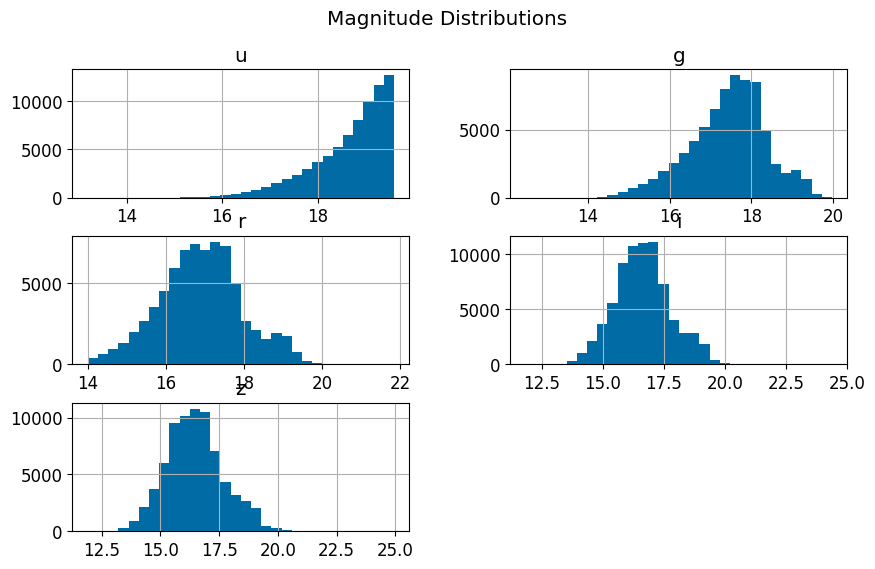

In [13]:
# Magnitude Distributions

mag_cols = ['u','g','r','i','z']
X_train[mag_cols].hist(bins=30, figsize=(10,6))
plt.suptitle("Magnitude Distributions")
plt.show()


# Color Distributions

This step creates color index features by computing differences between consecutive magnitude bands.

These color features capture the spectral characteristics of astronomical objects and are often more informative than raw magnitudes for classification tasks.

After creating the color features, their distributions are visualized using histograms to understand how each color index is distributed across the dataset. This helps reveal patterns, spread, and potential separation between different object classes.

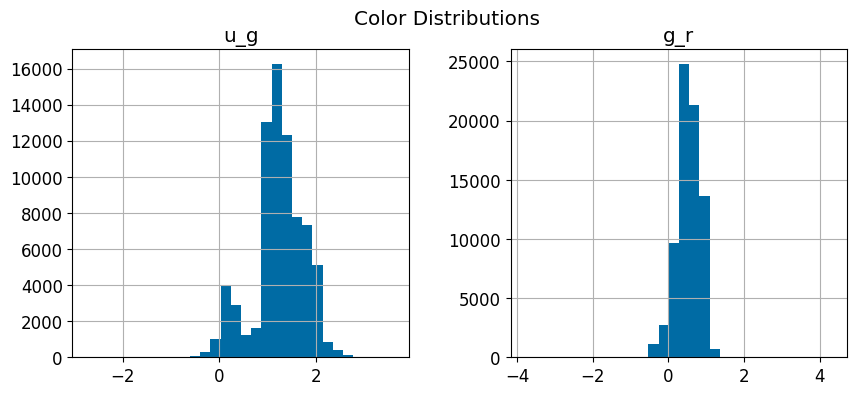

In [14]:
# Color Distributions
X_train_color = fe.transform(X_train)[["u_g", "g_r"]]

color_cols = ['u_g','g_r']
X_train_color.hist(bins=30, figsize=(10,4))
plt.suptitle("Color Distributions")
plt.show()


# Feature Correlation Heatmap

This step examines relationships between selected numerical features using a correlation matrix.

A subset of important photometric and morphological features is chosen, including colors, Petrosian radii, PSF magnitudes, and shape parameters. 

The correlation between these features is then computed and visualized using a heatmap.

This helps identify strongly correlated variables, which may indicate redundancy in the dataset and can guide feature selection or dimensionality reduction in later modeling steps.


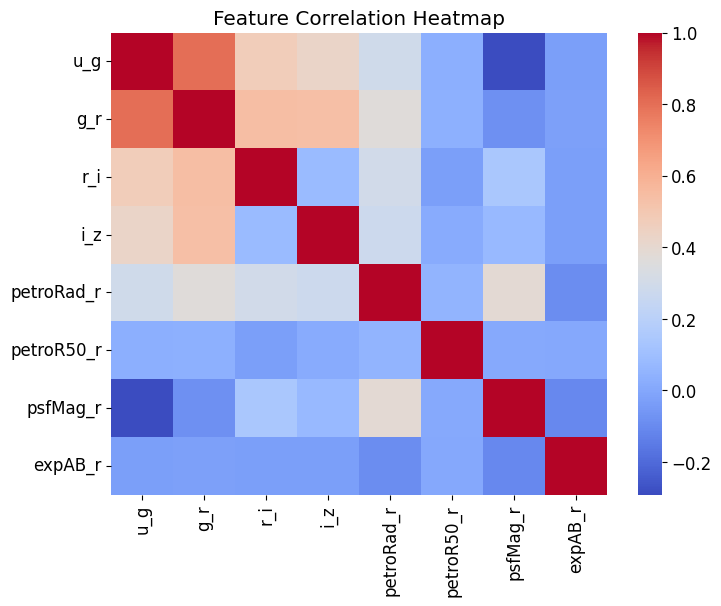

In [15]:
# Correlation Heatmap (sample features)

sample_cols = ['u_g','g_r','r_i','i_z','petroRad_r','petroR50_r','psfMag_r','expAB_r']
plt.figure(figsize=(8,6))
sns.heatmap(fe.transform(X_train)[sample_cols].corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()



# Class Separation in Color Space

This step visualizes how well different astronomical object classes can be separated using color indices.

A scatter plot is created using two key color features, g−r and r−i, which are known to carry strong astrophysical information. 

Each object class is plotted with a different color to observe how they cluster in this feature space.

This visualization helps assess whether stars, galaxies, and quasars form distinguishable regions, which is important for understanding how effectively these features can support classification models.


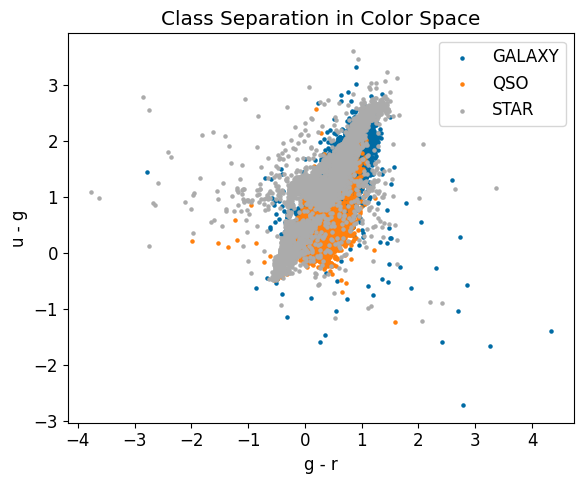

In [16]:
# ==========================================
# Class Separation in Color Space (FIXED)
# ==========================================

plt.figure(figsize=(6,5))

#for cls in class_names:
#    idx = (class_names[y]== cls)
for i, cls in enumerate(class_names):
    idx = (y_train == i)
    plt.scatter(X_train_color["g_r"][idx], X_train_color["u_g"][idx], label=cls, s=5)

plt.xlabel("g - r")
plt.ylabel("u - g")
plt.title("Class Separation in Color Space")
plt.legend()
plt.tight_layout()
plt.show()

### Class Imbalance in Astronomical Surveys

Astronomical datasets are rarely balanced.

Typical trends:
- Stars dominate (foreground objects in the Milky Way)
- Galaxies are numerous but extended
- Quasars are intrinsically rare

This imbalance affects how we evaluate models:
a classifier can achieve high accuracy by simply predicting the majority class.

Therefore, accuracy alone is not a reliable metric in survey science.

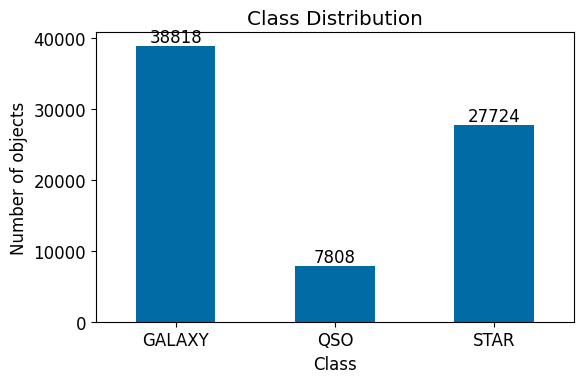

Class fractions:
 GALAXY    0.522098
QSO       0.105017
STAR      0.372885
Name: count, dtype: float64


In [17]:
# ==============================
# Class distribution
# ==============================

class_counts = pd.Series(y_train).value_counts().sort_index()
class_counts.index = class_names

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.ylabel("Number of objects")
plt.xlabel("Class")
plt.xticks(rotation=0)

# Annotate counts
for i, v in enumerate(class_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Also show fractions
class_frac = class_counts / class_counts.sum()
print("Class fractions:\n", class_frac)

### Why Are Quasars Rare?

Quasars (QSOs) are powered by accreting supermassive black holes.

They are rare because:

- Only a small fraction of galaxies host **actively accreting** black holes at any given time
- The quasar phase is **short-lived** compared to galaxy lifetimes
- They are often found at **high redshift**, making them observationally less common in shallow surveys

In contrast:
- Stars are abundant in the Milky Way
- Galaxies are common across the observable universe

This leads to a natural class imbalance where quasars form a small minority.

# PCA Visualization

This step reduces the dimensionality of the feature space using Principal Component Analysis (PCA) and visualizes the data in two dimensions.

The full feature matrix is projected onto its first two principal components, which capture the directions of highest variance in the data. 

This allows complex high-dimensional structure to be visualized in a simplified 2D space.

Each object class is then plotted separately to observe how well different classes cluster after dimensionality reduction. 

This helps assess whether the feature space contains separable structure that can be exploited by machine learning models.

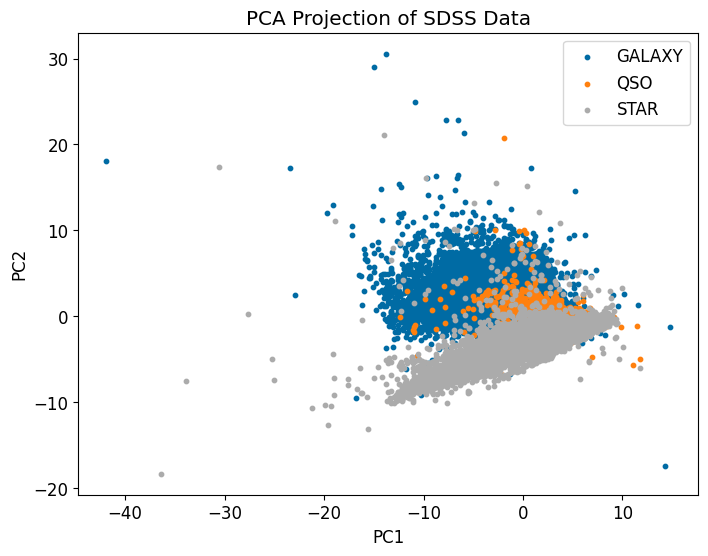

In [18]:
## Use feature matrix (ensure numeric only)
pca_pipeline2 = Pipeline([
    ("features", FeatureEngineer()),
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=SEED))
])


X_train_pca2 = pca_pipeline2.fit_transform(X_train)

plt.figure(figsize=(8,6))

for cls in np.unique(y_train):
    idx = (y_train == cls)
    plt.scatter(X_train_pca2[idx, 0], X_train_pca2[idx, 1], label=class_names[cls], s=10)

plt.title("PCA Projection of SDSS Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()



### Interpreting PCA Components

PCA is not just a visualization tool—it reveals which physical features drive variance.
- PCA suggests **dominant variance directions**, which may correlate with physical properties


In [19]:
# ==========================================
# Class separability (supervised, meaningful)
# ==========================================

from itertools import combinations

def class_separation_score(X, y):
    """
    Computes average pairwise class separation:
    distance between class means / within-class scatter
    """
    classes = np.unique(y)
    scores = []

    for c1, c2 in combinations(classes, 2):
        X1 = X[y == c1]
        X2 = X[y == c2]

        mean_dist = np.linalg.norm(X1.mean(axis=0) - X2.mean(axis=0))
        scatter = np.trace(np.cov(X1, rowvar=False)) + np.trace(np.cov(X2, rowvar=False))

        scores.append(mean_dist / (scatter + 1e-8))

    return np.mean(scores)



In [20]:
# ==============================
# PCA: What drives the components?
# ==============================

pca_pipeline5 = Pipeline([
    ("features", FeatureEngineer()),
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=5, random_state=SEED))
])

X_train_pca5 = pca_pipeline5.fit_transform(X_train)

# Loadings
loadings = pd.DataFrame(
    pca_pipeline5.named_steps["pca"].components_,
    columns=pca_pipeline5.named_steps["features"].get_feature_names_out(X_train.columns),
    index=[f"PC{i+1}" for i in range(5)]
)


# Show top drivers for PC1 and PC2
for pc in ["PC1", "PC2"]:
    print(f"\nTop drivers of {pc}")
    display(loadings.loc[pc].sort_values(ascending=False).head(8))
    display(loadings.loc[pc].sort_values().head(8))


Top drivers of PC1


r           0.295350
i           0.294556
z           0.293150
g           0.282377
psfMag_z    0.201231
u           0.199019
psfMag_i    0.180176
psfMag_r    0.161043
Name: PC1, dtype: float64

petroFlux_r     -0.268906
petroFlux_i     -0.267995
petroFlux_z     -0.249357
petroFlux_g     -0.237570
u_g             -0.202411
g_r             -0.164687
petroFlux_u     -0.155231
petroRad_mean   -0.133284
Name: PC1, dtype: float64


Top drivers of PC2


psfMag_u       0.304682
psfMag_g       0.291074
psf_shape_r    0.288488
psf_shape_g    0.277687
psfMag_r       0.263072
psf_shape_i    0.260923
psfMag_i       0.242382
petroRad_r     0.234491
Name: PC2, dtype: float64

expAB_std     -0.228690
petroFlux_g   -0.098792
petroFlux_u   -0.097413
expAB_g       -0.076904
petroFlux_r   -0.067895
expAB_r       -0.056280
expAB_mean    -0.055362
petroFlux_i   -0.041903
Name: PC2, dtype: float64

In [21]:
sep_score = class_separation_score(X_train_pca5[:, :2], y_train)
print("Class separability score (PCA 2D):", sep_score)

Class separability score (PCA 2D): 0.2923555495424655


# Decision Boundary Visualization in Color Space

This step trains a simple classification model and visualizes its decision regions in a two-dimensional color feature space.

A logistic regression model is trained using two color indices, u−g and g−r, which are highly informative for distinguishing astronomical object classes. 

The features are standardized before training to ensure stable model convergence.

To visualize the learned decision boundaries, a dense grid is created over the feature space. 

The trained model predicts a class label for each point in this grid, allowing the construction of a continuous classification map.

The resulting decision regions are plotted as a background, and the actual data points are overlaid on top. 

This provides an intuitive view of how the model separates different object classes in the chosen feature space.

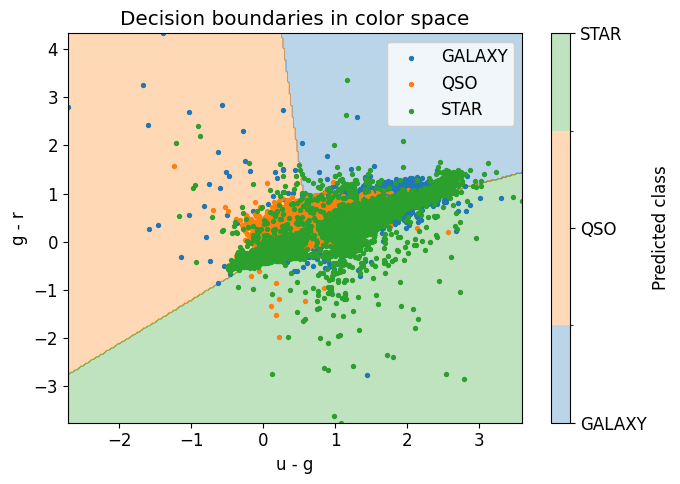

In [22]:
# Build color-only dataset directly from raw features

vis_model = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, random_state=SEED, solver="lbfgs"))
])

vis_model.fit(X_train_color, y_train)

x_min, x_max = X_train_color["u_g"].min(), X_train_color["u_g"].max()
y_min, y_max = X_train_color["g_r"].min(), X_train_color["g_r"].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame({
    "u_g": xx.ravel(),
    "g_r": yy.ravel()
})

Z = vis_model.predict(grid)
Z = Z.reshape(xx.shape)

from matplotlib.colors import ListedColormap, BoundaryNorm

plt.figure(figsize=(7,5))

# Number of classes
n_classes = len(class_names)

# Discrete colormap
cmap = ListedColormap(plt.cm.tab10.colors[:n_classes])
norm = BoundaryNorm(np.arange(-0.5, n_classes + 0.5, 1), n_classes)

# Decision regions
contour = plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap, norm=norm)

# Proper discrete colorbar
cbar = plt.colorbar(contour, ticks=np.arange(n_classes))
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Predicted class")

custom_colors = ["tab:blue", "tab:orange", "tab:green"]
# Scatter points
for i,cls in enumerate(np.unique(y_train)):
    idx = (y_train == cls)
    plt.scatter(
        X_train_color.loc[idx, "u_g"],
        X_train_color.loc[idx, "g_r"],
        label=class_names[cls], color=custom_colors[i],
        s=8
    )

plt.xlabel("u - g")
plt.ylabel("g - r")
plt.title("Decision boundaries in color space")
plt.legend()
plt.tight_layout()
plt.show()

# Model Training and Evaluation

This step trains two different classification models and evaluates their performance on the test set.

A logistic regression model is trained with feature scaling to learn linear decision boundaries in the transformed feature space. In parallel, a random forest classifier is trained as a more flexible non-linear model that can capture complex relationships between features.

Both models are fitted using the training data. The random forest model is then used to generate predictions on the test set.

Two types of outputs are considered from the random forest:
- hard labels, which represent the final predicted class for each object
- class probabilities, which provide a confidence distribution over all possible classes

Finally, the accuracy of the random forest model is computed on the test set to evaluate its overall classification performance.

In [23]:
# linear boundaries in transformed feature space
logit = Pipeline([
    ("features", FeatureEngineer()),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        random_state=SEED, 
        solver="lbfgs",
        class_weight="balanced"
    ))
])

rf = Pipeline([
        ("features", FeatureEngineer()),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=SEED,
            n_jobs=-1, 
            class_weight="balanced_subsample"
        ))
])

logit.fit(X_train, y_train)
rf.fit(X_train, y_train)

pred_logit = logit.predict(X_test)
proba_logit = logit.predict_proba(X_test)

pred_rf = rf.predict(X_test)
# This gives you the final "Hard Label" (e.g., "This is a Star"). 
# It chooses the class with the highest probability.

proba_rf = rf.predict_proba(X_test)
# This gives you the "Soft Label" (e.g., [Star: 0.1, Galaxy: 0.8, Quasar: 0.1]).

print("Logistic Regression accuracy:", accuracy_score(y_test, pred_logit))

print("Random Forest accuracy:      ", accuracy_score(y_test, pred_rf))


Logistic Regression accuracy: 0.971150742414461
Random Forest accuracy:       0.983255326016785


# Classification Performance Report

This step evaluates the performance of the trained model using a detailed classification report.

The report compares the predicted labels with the true labels from the test set and provides several evaluation metrics for each class.

These metrics include precision, recall, and F1-score, which together describe how well the model is performing for each category. 

Precision measures how many predicted positives are correct, recall measures how many actual positives are correctly identified, and F1-score provides a balanced measure between the two.

This evaluation is important for understanding not only overall accuracy but also class-wise performance, especially in cases where class distributions may be imbalanced.

In [24]:
print("Classification Report:")
#print(classification_report(y_test, pred_logit))
print(classification_report(y_test, pred_logit, target_names=class_names))


print("Balanced accuracy:", balanced_accuracy_score(y_test, pred_logit))

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.99      0.98      0.99     12940
         QSO       0.84      0.94      0.89      2603
        STAR       0.98      0.97      0.98      9241

    accuracy                           0.97     24784
   macro avg       0.94      0.96      0.95     24784
weighted avg       0.97      0.97      0.97     24784

Balanced accuracy: 0.9629795119669526


In [25]:
print("Classification Report:")
#print(classification_report(y_test, pred_rf))
print(classification_report(y_test, pred_rf, target_names=class_names))

print("Balanced accuracy:", balanced_accuracy_score(y_test, pred_rf))

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.99      0.99      0.99     12940
         QSO       0.96      0.92      0.94      2603
        STAR       0.99      0.99      0.99      9241

    accuracy                           0.98     24784
   macro avg       0.98      0.97      0.97     24784
weighted avg       0.98      0.98      0.98     24784

Balanced accuracy: 0.9665700157621183


# Confusion Matrix Visualization

This step evaluates the classification results using a confusion matrix.

The confusion matrix compares the true class labels with the predicted labels from the model, showing how many samples were correctly and incorrectly classified for each class.

A heatmap is used to visualize the matrix, making it easier to interpret patterns of misclassification. Each row represents the true class, while each column represents the predicted class.

This helps identify which object types are being confused by the model and provides insight into specific weaknesses in classification performance.

Confusion Matrix:


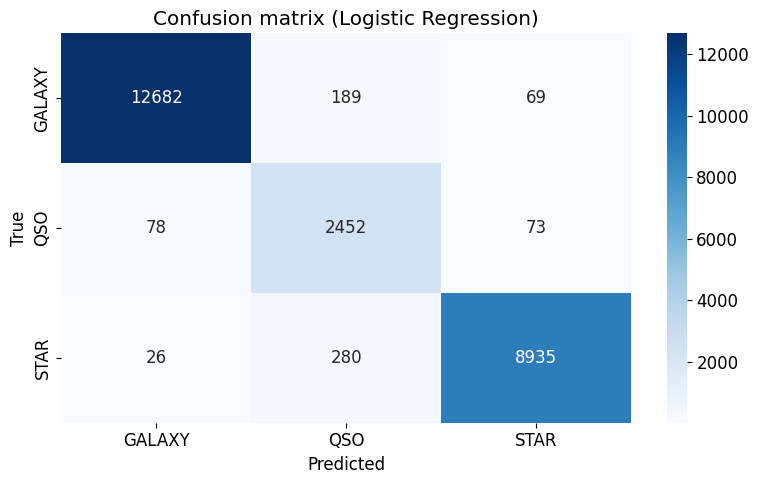

In [26]:
print("Confusion Matrix:")

cm = confusion_matrix(y_test, pred_logit)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


Confusion Matrix:


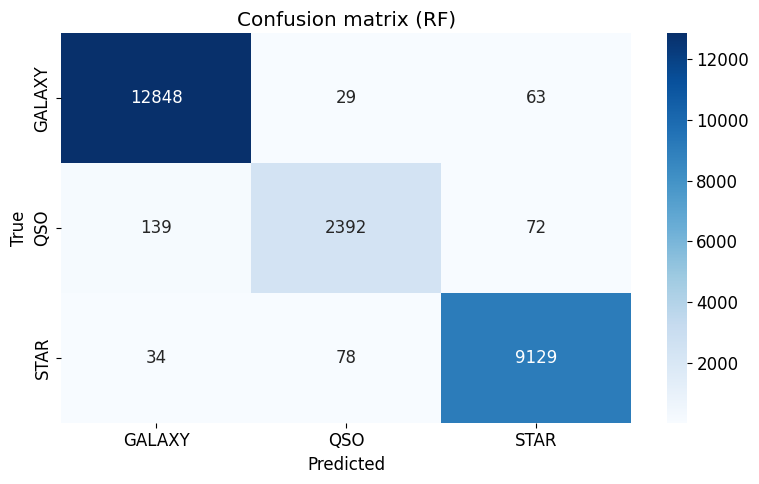

In [27]:
print("Confusion Matrix:")

cm = confusion_matrix(y_test, pred_rf)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion matrix (RF)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


### Logistic Regression as a Physical Model

Logistic regression learns smooth decision boundaries in color space.

This is conceptually similar to classical astronomy selection cuts:

- Quasars: UV excess → low (u−g)
- Galaxies: redder colors
- Stars: follow stellar locus

The model generalizes these ideas into probabilistic form:
instead of hard cuts, we obtain continuous likelihoods.

Coefficients:
- are shown in standardized feature space and should be interpreted comparatively, not as direct physical sensitivities.
- indicate which standardized features most influence decision boundaries, but do not directly map to physical causation.

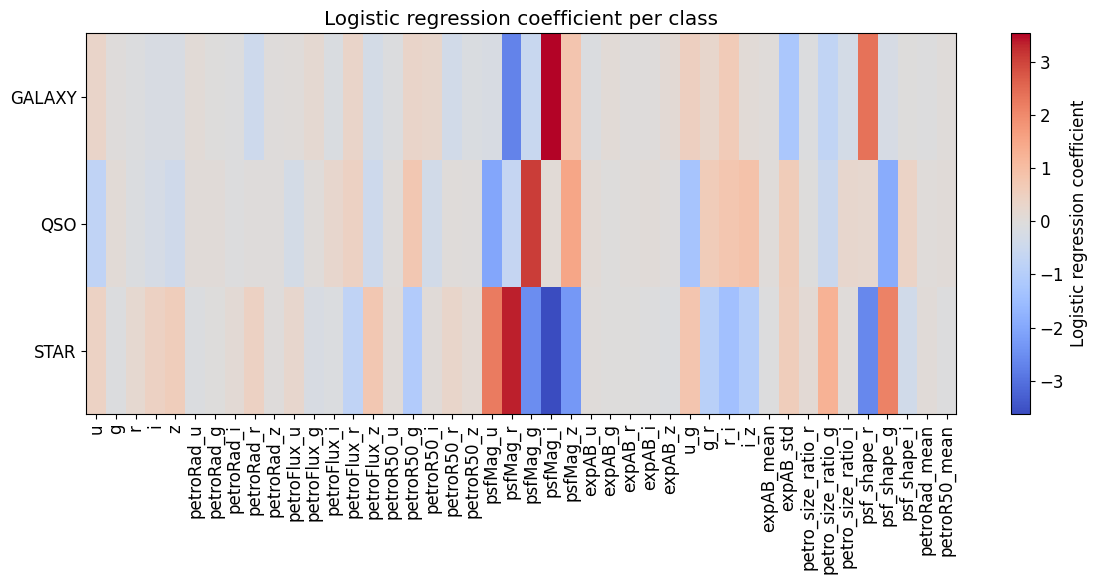

In [28]:
coef = logit.named_steps["clf"].coef_

coef_df = pd.DataFrame(
    coef,
    index=class_names,
    columns=logit.named_steps["features"].get_feature_names_out(X_train.columns),
)

plt.figure(figsize=(12, 6))

im = plt.imshow(coef_df, aspect="auto", cmap="coolwarm")

plt.yticks(range(len(class_names)), class_names)
plt.xticks(range(len(logit.named_steps["features"].get_feature_names_out(X_train.columns))), 
           logit.named_steps["features"].get_feature_names_out(X_train.columns), rotation=90)

plt.colorbar(im, label="Logistic regression coefficient")

plt.title("Logistic regression coefficient per class")
plt.tight_layout()
plt.show()

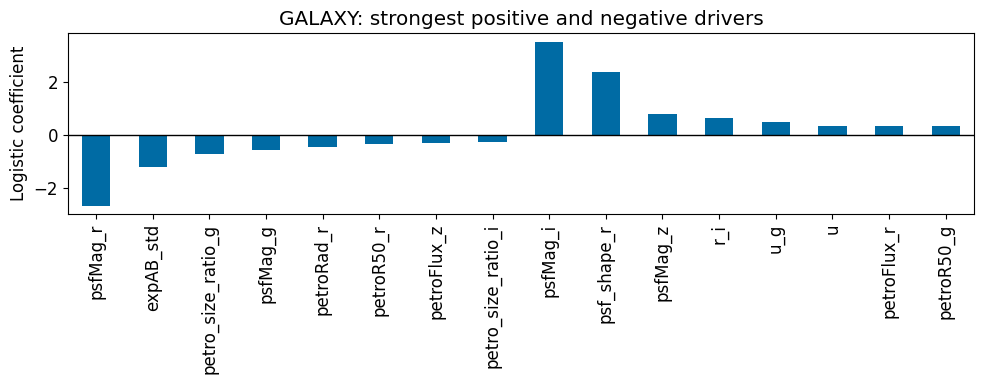

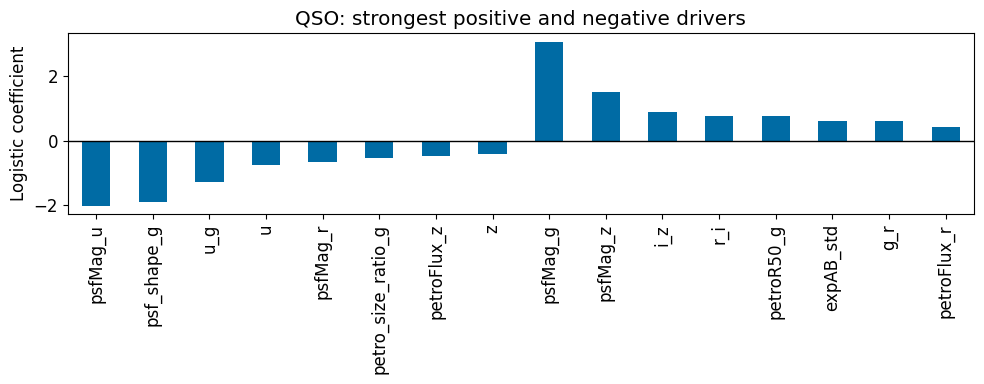

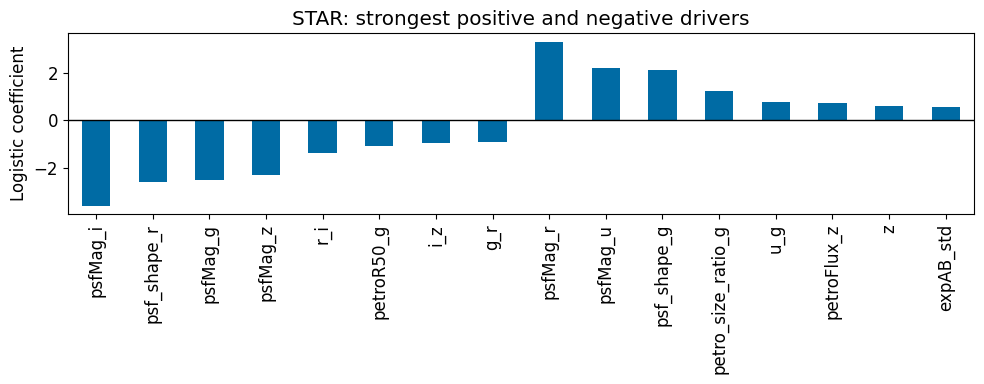

In [29]:
for i, cls in enumerate(class_names):

    coef_series = pd.Series(coef[i], index=logit.named_steps["features"].get_feature_names_out(X_train.columns))

    top = pd.concat([
        coef_series.sort_values().head(8),
        coef_series.sort_values(ascending=False).head(8)
    ])

    plt.figure(figsize=(10, 4))
    top.plot(kind="bar")

    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"{cls}: strongest positive and negative drivers")
    plt.ylabel("Logistic coefficient")
    plt.tight_layout()
    plt.show()

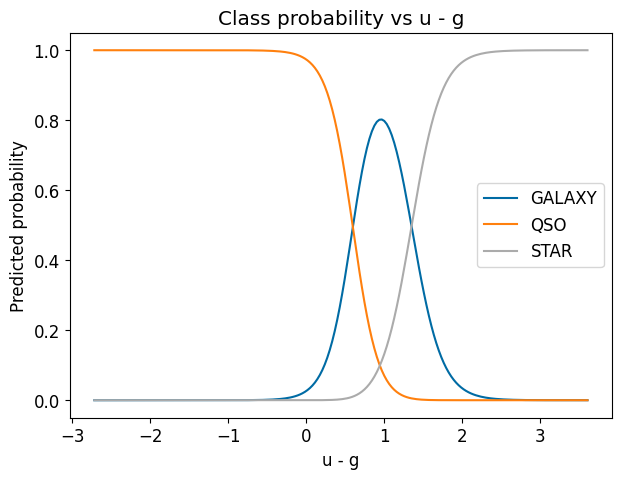

In [30]:
# ==========================================
# Logistic regression: probability vs color
# (clean 2D probe version)
# ==========================================

# Build color space directly
u_g_range = np.linspace( X_train_color["u_g"].min(), X_train_color["u_g"].max(), 200)

g_r_fixed = np.median(X_train_color["g_r"])

X_range_color = pd.DataFrame({
    "u_g": u_g_range,
    "g_r": g_r_fixed
})

# Train a simple model in the SAME space (important!)
vis_model = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, random_state=SEED, solver="lbfgs"))
])

vis_model.fit(X_train_color, y_train)

# Predict probabilities
probs = vis_model.predict_proba(X_range_color)

# Plot
plt.figure(figsize=(7,5))
for i, cls in enumerate(class_names):
    plt.plot(u_g_range, probs[:, i], label=cls)

plt.xlabel("u - g")
plt.ylabel("Predicted probability")
plt.title("Class probability vs u - g")
plt.legend()
plt.show()

### Random Forest feature importances


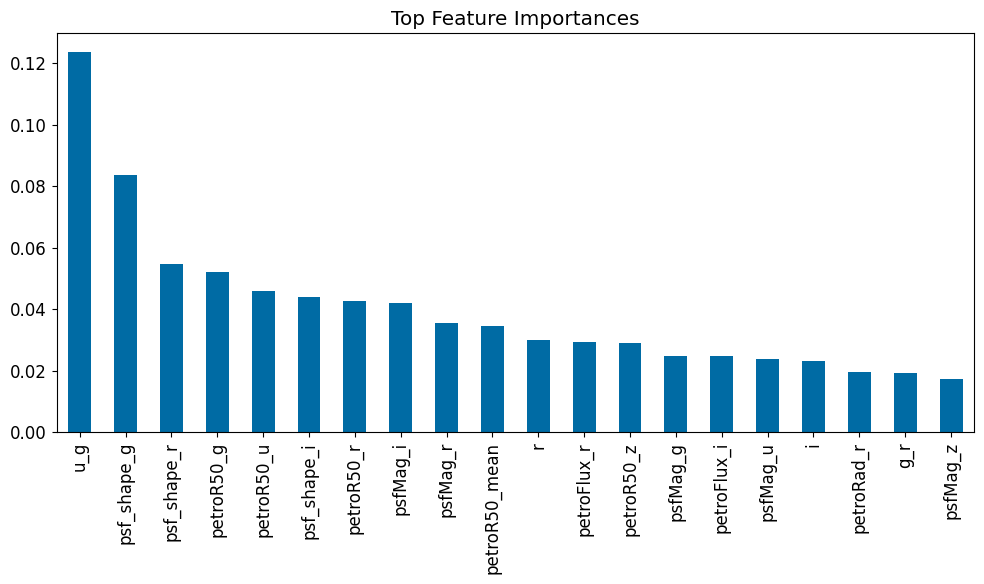

In [31]:
importances = rf.named_steps["clf"].feature_importances_

feat_importance = pd.Series(
    importances,
    index=rf.named_steps["features"].get_feature_names_out(X_train.columns)
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_importance.head(20).plot(kind="bar")
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()

# SHAP Explainability Analysis

This step applies SHAP (SHapley Additive exPlanations) to interpret the predictions of the Random Forest model.

A subset of the test data is used to reduce computational cost while still providing a representative view of model behavior. 

A TreeExplainer is then initialized on the trained Random Forest model to compute feature contributions for each prediction.

SHAP values quantify how much each feature influences the model’s output, either increasing or decreasing the predicted probability for a given class. 

This provides a detailed, local and global explanation of model decisions.

The resulting values can be used to generate summary plots that highlight the most important features driving the model’s predictions.

Notice that the interpretation for  highly correlated features (colors, magnitudes) is tricky:

- As a consequence, SHAP values can redistribute importance arbitrarily especially between correlated colors.

- Therefore, feature importance should be interpreted at the level of feature groups (e.g., colors vs morphology), not individual variables.


In conclusion, because photometric features are correlated, SHAP values should be interpreted as indicative rather than uniquely causal.

In [32]:
# Use small sample for speed
# You are calculating the "Global Feature Importance" for your Random Forest.

X_shap = X_test.sample(min(400, len(X_test)), random_state=SEED)
X_shap_fe = rf.named_steps["features"].transform(X_shap)

explainer = shap.TreeExplainer(rf.named_steps["clf"])
print("Generating SHAP summary plot...")


Generating SHAP summary plot...


## SHAP Explainability Analysis

### Why SHAP?

Machine learning models like Random Forests can achieve high performance, but their internal decision-making is not directly interpretable.

SHAP (SHapley Additive exPlanations) provides a principled way to:
- quantify how each feature contributes to a prediction
- interpret model behavior both globally and locally
- verify whether the model is learning physical structure rather than spurious correlations


In [33]:
# Use a subset for speed

def get_shap_values(explainer, X):
    """
    Returns SHAP values in shape:
    (n_samples, n_features, n_classes)
    Works across SHAP versions.
    """
    sv = explainer.shap_values(X)

    # Old API: list of arrays (one per class)
    if isinstance(sv, list):
        return np.stack(sv, axis=-1)

    # New API: already in correct shape
    return sv

shap_values = get_shap_values(explainer, X_shap_fe)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (400, 44, 3)


### SHAP Summary Plot for Global Feature Effects

This step visualizes the global impact of features on the model’s predictions using SHAP values.

Since the problem is multiclass, SHAP values are computed separately for each class and aggregated internally by the visualization. 

The summary plot shows how each feature contributes to pushing predictions toward or away from specific classes.

Each point in the plot represents a single sample, and the position along the x-axis indicates the magnitude and direction of the feature’s impact. 

Features are ranked by overall importance, allowing identification of the most influential variables in the model.

This provides an interpretable view of how the Random Forest model uses different astrophysical features to make classification decisions.


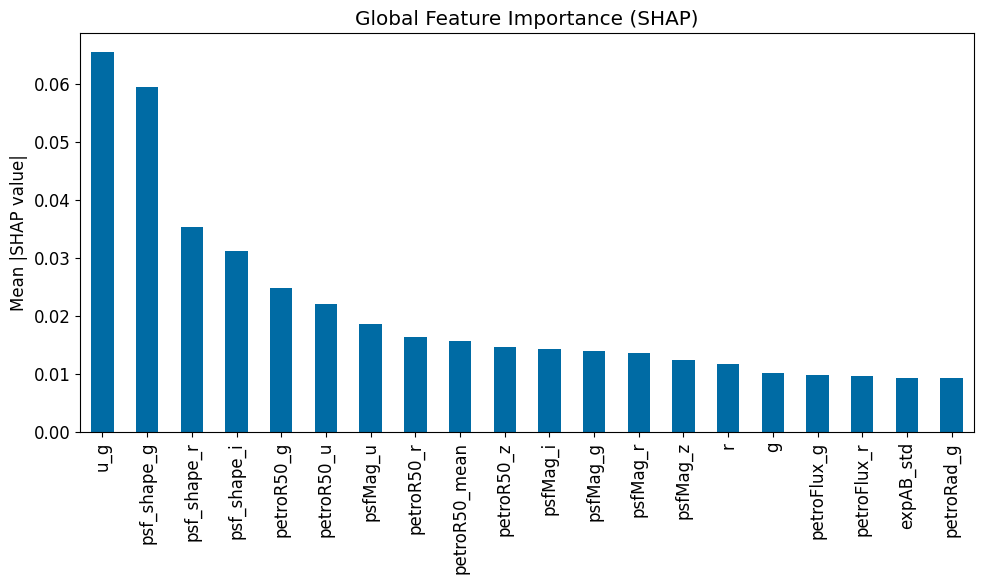

In [34]:
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.Series(mean_abs_shap, 
            index=rf.named_steps["features"].get_feature_names_out(X_train.columns)).sort_values(ascending=False)

plt.figure(figsize=(10,6))
shap_importance.head(20).plot(kind="bar")

plt.title("Global Feature Importance (SHAP)")
plt.ylabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

### Interpreting SHAP in Astrophysical Terms

SHAP identifies which features drive classification decisions.

For quasars, we expect:

- Low (u−g): ultraviolet excess from accretion disk
- Point-like morphology: unresolved at SDSS resolution
- Specific color combinations separating them from stars

If the model highlights these features, it confirms that:
the classifier is learning real astrophysical structure,


Here we focus on a single class (QSO).

The plot shows how each feature pushes predictions:
- toward the QSO class (positive SHAP values)
- away from it (negative SHAP values)


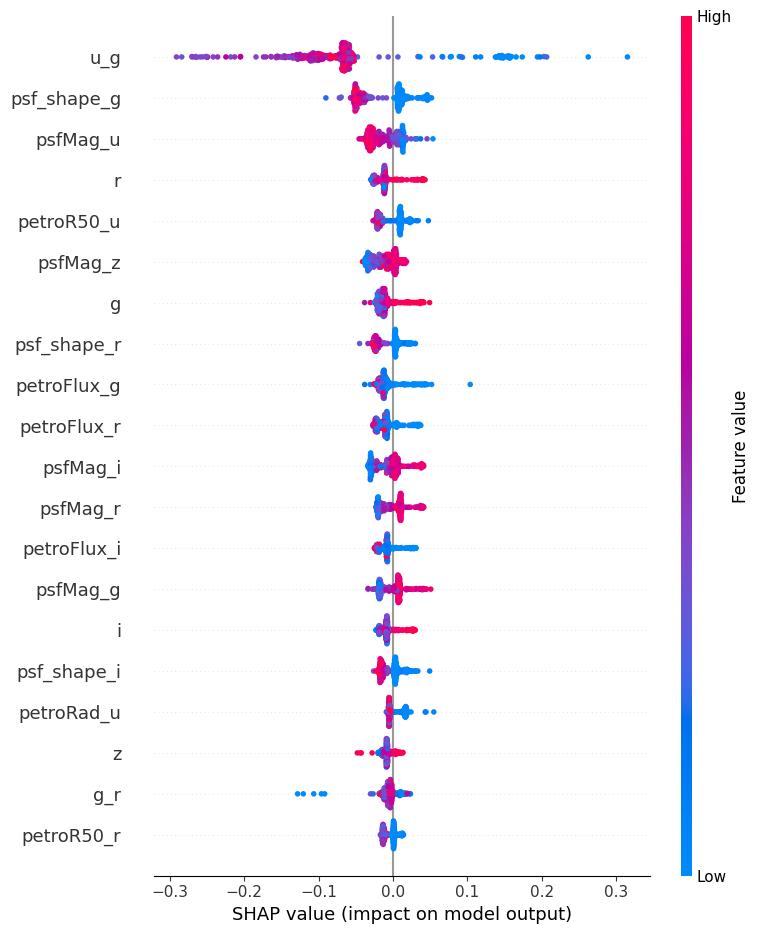

In [35]:
#qso_idx = list(class_names).index("QSO")
#qso_idx = np.where(class_names == "QSO")[0][0]
if "QSO" not in class_names:
    raise ValueError("QSO class not found")

qso_idx = np.where(class_names == "QSO")[0][0]
sv_qso = shap_values[:, :, qso_idx]

shap.summary_plot(sv_qso, X_shap_fe)

In [36]:
# ==========================================
# QSO-specific feature importance
# ==========================================

mean_abs_qso = np.abs(sv_qso).mean(axis=0)

qso_importance = pd.Series(mean_abs_qso, 
            index=rf.named_steps["features"].get_feature_names_out(X_train.columns)).sort_values(ascending=False)

print("Top features driving QSO classification:")
print(qso_importance.head(15))

Top features driving QSO classification:
u_g            0.098139
psf_shape_g    0.030961
psfMag_u       0.018941
r              0.017430
petroR50_u     0.015303
psfMag_z       0.015253
g              0.015205
psf_shape_r    0.014830
petroFlux_g    0.014652
petroFlux_r    0.014409
psfMag_i       0.014355
psfMag_r       0.013770
petroFlux_i    0.012518
psfMag_g       0.012387
i              0.012312
dtype: float64


# Local Explanation with SHAP Waterfall Plot

This step explains an individual prediction using SHAP values to understand how each feature contributes to the model’s decision.

A single test sample is selected, and the trained model is used to predict its class. 

The true label and predicted label are printed for comparison.

SHAP values are then computed for this single observation. 

A waterfall plot is generated to show how each feature pushes the prediction away from the model’s baseline expectation toward the final output.

Positive contributions increase the likelihood of the predicted class, while negative contributions decrease it. 

This provides a detailed breakdown of the model’s reasoning for a single prediction, making the decision process interpretable at the instance level.

### Local Explanation: Physical Interpretation

This object is classified as a quasar because:

- Its colors push the prediction toward the quasar class (UV excess)
- Its morphology is consistent with a point source
- Competing features (e.g. galaxy-like size) are weak

SHAP allows us to translate a machine learning prediction into a physically interpretable explanation.

In [37]:
# ==========================================
# Local explanation (single object)
# ==========================================

# Find indices where true label AND prediction are both QSO
high_conf_qso_candidates = np.where((y_test == qso_idx) & (pred_rf == qso_idx))[0]

# Safety check: avoid crash if no such sample exists
if len(high_conf_qso_candidates) == 0:
    raise ValueError("No correctly predicted QSO found in test set.")

# Pick first candidate
high_conf_qso_idx = high_conf_qso_candidates[0]

# Select object
obj = X_test.iloc[[high_conf_qso_idx]]

# Predict again for this object (for consistency)
pred = rf.predict(obj)[0]

print("True label:", class_names[y_test[high_conf_qso_idx]])
print("Predicted:", class_names[pred])


True label: QSO
Predicted: QSO


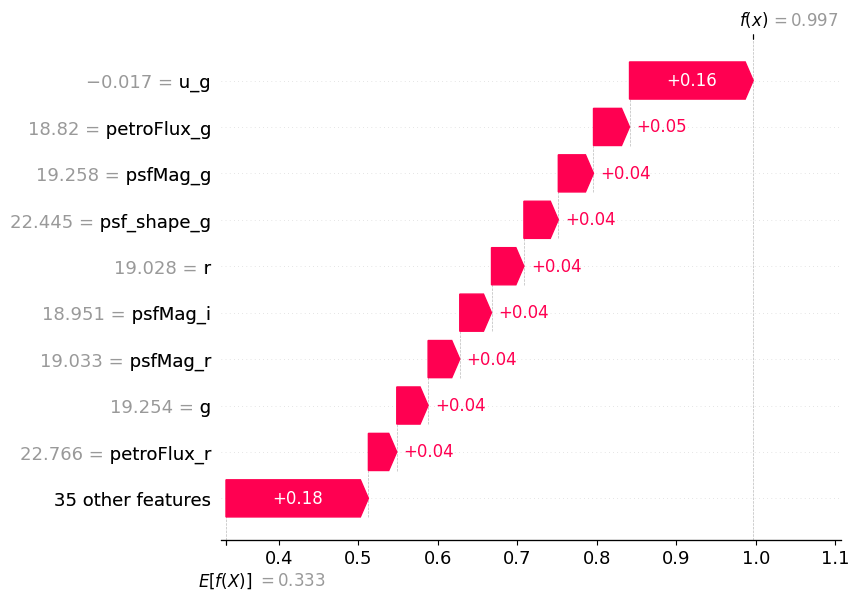

In [38]:
obj_fe = rf.named_steps["features"].transform(obj)

# Compute SHAP values safely (must be defined elsewhere)
sv_one = get_shap_values(explainer, obj_fe)

# Extract SHAP values for predicted class
sv = sv_one[0, :, pred]

# Base value (expected model output)
base = explainer.expected_value[pred]
base = explainer.expected_value
if isinstance(base, (list, np.ndarray)):
    base = base[pred]
    
# Build explanation object
exp = shap.Explanation(
    values=sv,
    base_values=base,
    data=obj_fe.iloc[0],
    feature_names=rf.named_steps["features"].get_feature_names_out(X_train.columns)
)

shap.plots.waterfall(exp)

### Interpreting the Local Explanation

The waterfall plot shows how the prediction is built:
- The baseline is the average model output

Each feature pushes the prediction:
- upward → toward the predicted class
- downward → away from it

### Astrophysical reading

For a quasar prediction, we typically expect:
- colors consistent with UV excess
- morphology consistent with a point source
- absence of strong galaxy-like size indicators

This allows us to translate a machine learning output into a physically interpretable explanation.

## Probability Calibration (Rewritten, Modern & Pedagogical)

### Why Calibration Matters

A classifier may assign high probability to a class without that probability being statistically meaningful.

For example:

- Predictions with 0.9 confidence should be correct ~90% of the time

- If not, the model is miscalibrated

In survey science, this is critical:

> We rank objects by probability to allocate telescope time.

### Calibration Strategy

We use cross-validated calibration via `CalibratedClassifierCV`.

This approach:

- splits the training data internally into folds
- trains the base model on each fold
- learns calibration mappings on held-out folds
- averages the calibrated models

This avoids:

- wasting data in a separate calibration set
- information leakage
- unstable calibration curves

# Probability Calibration of the Classifier

This step improves the reliability of the model’s predicted probabilities using calibration techniques.

A pre-trained Random Forest model is wrapped inside a calibration framework so that its outputs can be adjusted without retraining the full model. 

The calibration is performed using a separate calibration dataset.

Two calibration methods are applied and compared:

- Sigmoid (Platt scaling), which fits a parametric sigmoid function to map raw model scores to calibrated probabilities
- Isotonic regression, which uses a non-parametric approach and can capture more flexible calibration curves

After fitting on the calibration set, both calibrated models are used to generate probability estimates on the test set. 

These calibrated probabilities are typically better aligned with true likelihoods than raw model outputs.

In [ ]:
# ==========================================
# Base and calibrated models
# ==========================================

rf_params = dict(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced_subsample"
)


# Calibrated versions
rf_platt = Pipeline([
        ("features", FeatureEngineer()),
        ("clf", CalibratedClassifierCV(
            estimator=RandomForestClassifier(**rf_params),
            method="sigmoid",   # Platt scaling
            cv=5                # cross-validated calibration
        ))
])

rf_iso = Pipeline([
        ("features", FeatureEngineer()),
        ("clf", CalibratedClassifierCV(
            estimator=RandomForestClassifier(**rf_params),
            method="isotonic",  # flexible non-parametric calibration
            cv=5
        ))
])

# Fit models
rf_platt.fit(X_train, y_train)
rf_iso.fit(X_train, y_train)

# Predict probabilities
proba_rf_platt = rf_platt.predict_proba(X_test)
proba_rf_iso = rf_iso.predict_proba(X_test)

## Confidence Distribution and the Impact of Calibration

This step examines how calibration affects the **confidence of model predictions**.

Instead of focusing only on which class is predicted, we analyze **how certain the model is** in its predictions.

###### What is being measured?

For each object, we extract:

- the **maximum predicted probability across all classes**

This represents the model’s **confidence in its chosen label**.

We compute this for three models:

- **Uncalibrated Random Forest**
- **Platt-scaled (sigmoid) calibration**
- **Isotonic calibration**

###### Why this matters

A well-calibrated model should produce probabilities that are:

- **not overconfident** (avoiding artificially high probabilities)
- **not underconfident** (retaining useful distinctions between candidates)

In survey science, confidence directly affects:

> which objects are selected for follow-up observations

###### Visualization

We plot histograms of prediction confidence for each model.

Key features:

- Each curve shows how many objects fall into a given confidence range  
- Step-style histograms are used to avoid visual overlap  

###### Physically meaningful thresholds

Two reference lines are added:

- **0.33 (random guessing)**  
  - no discriminative power  

- **0.95 ("science-grade" confidence)**  
  - typical threshold for high-priority follow-up targets  

Notice that a model can be perfectly calibrated but useless if it predicts ~0.33 for everything.

###### Interpretation

Calibration changes how confidence is distributed:

- **Uncalibrated models** often:
  - concentrate predictions near 1.0  
  - appear overconfident  

- **Platt scaling**:
  - smooths probabilities  
  - reduces extreme confidence  

- **Isotonic regression**:
  - provides more flexible adjustments  
  - can better match true probability structure  

###### Summary statistics

A table is computed to quantify these effects:

- **Mean confidence**
- **Median confidence**
- **Number of high-confidence predictions (> 0.95)**

This allows direct comparison of how calibration affects:

- overall confidence level  
- number of “science-grade” candidates  

###### Scientific takeaway

Calibration is not just a statistical correction:

> it directly controls how many objects we trust enough to observe

A model that is slightly less confident—but better calibrated—can lead to:

- more efficient telescope time usage  
- higher purity in selected samples  
- more reliable scientific conclusions  


In [ ]:
# Random baseline (correct)
random_probs = rng.dirichlet(np.ones(len(class_names)), size=len(y_test))
random_conf = random_probs.max(axis=1)

conf_data = pd.DataFrame({
    'Uncalibrated': proba_rf.max(axis=1),
    'Platt': proba_rf_platt.max(axis=1),
    'Isotonic': proba_rf_iso.max(axis=1),
    'Random Classifier': random_conf
})

plt.figure(figsize=(10, 6))
colors = ['#e31a1c', '#33a02c', '#1f78b4', '#7f7f7f']
for i,col in enumerate(conf_data.columns):
    sns.histplot(conf_data[col], label=col, element="step", fill=False, bins=40, color=colors[i])

plt.axvline(0.95, color='orange', linestyle='--', label='Selection threshold')

plt.title("Prediction Confidence: Calibration vs Random Model")
plt.xlabel("Max class probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# Extracting Class-Specific Probabilities (Binary Reformulation)

This step converts the multiclass classification problem into a binary perspective for a single class of interest, in this case quasars (QSO).

A helper function is defined to extract the predicted probability corresponding to a chosen class from the full probability distribution output of the model. 

This is done by locating the index of the target class and selecting its associated probability column.

The true labels are also converted into a binary indicator, where the target class is marked as 1 and all other classes are marked as 0. 

This allows direct comparison between predicted probabilities and actual class membership.

Finally, the quasar probabilities are extracted from three different models: the raw Random Forest, the Platt-scaled model, and the isotonic-calibrated model. 

This enables evaluation of how calibration affects probability estimates for a specific scientific class of interest.

In [ ]:
#def get_class_prob(proba, classes, label):
#    idx = list(classes).index(label)
#    return proba[:, idx]


In [ ]:
# ==========================================
# Focus on quasars (QSO)
# ==========================================

#qso_idx = list(class_names).index("QSO")
#qso_idx = np.where(class_names == "QSO")[0][0]
if "QSO" not in class_names:
    raise ValueError("QSO class not found")

qso_idx = np.where(class_names == "QSO")[0][0]

qso_true = (y_test == qso_idx).astype(int)

qso_rf       = proba_rf[:, qso_idx]
qso_rf_platt = proba_rf_platt[:, qso_idx]
qso_rf_iso   = proba_rf_iso[:, qso_idx]


### From Classification to Decision-Making

In real surveys, we do not classify all objects—we select a small subset for follow-up.

This becomes a **resource allocation problem**:

- Telescope time is limited
- Observations are expensive
- We must maximize scientific return

Ranking by calibrated probability allows us to:
- prioritize high-confidence candidates
- maximize the expected number of true discoveries

This is why **probability calibration is more important than raw accuracy**.

In practice, selection may optimize expected scientific return rather than raw precision.


In [ ]:
# ==========================================
# Telescope allocation simulation
# ==========================================

N = 20  # number of objects we can observe

# Rank by quasar probability
rank_idx = np.argsort(qso_rf_iso)[::-1]

top_idx = rank_idx[:N]

# True number of quasars recovered
n_qso_found = qso_true[top_idx].sum()

print(f"Selected {N} candidates")
print(f"Recovered QSOs: {n_qso_found}")
print(f"Precision: {n_qso_found / N:.3f}")

In [ ]:
# Random baseline
#rand_idx = np.random.choice(len(qso_true), N, replace=False)
rand_idx = rng.choice(len(qso_true), N, replace=False)
print("Random QSOs:", qso_true[rand_idx].sum())

# Threshold strategy
threshold = 0.9
thresh_idx = np.where(qso_rf_iso > threshold)[0][:N]
print("Threshold QSOs:", qso_true[thresh_idx].sum())

# Reliability Diagram for Model Calibration

This step evaluates how well the predicted probabilities align with actual outcomes using a reliability diagram.

A calibration curve is computed by grouping predictions into bins and comparing the average predicted probability with the observed frequency of the positive class in each bin. 

This provides a direct measure of probability calibration quality.

A helper function is defined to generate and plot these calibration curves for different models. 

The diagram includes results from the raw Random Forest model as well as the two calibrated versions using Platt scaling and isotonic regression.

A perfect calibration reference line is also included, where predicted probabilities match observed frequencies exactly. Deviations from this line indicate miscalibration.

This visualization helps assess which calibration method produces the most reliable probability estimates for the target class.


In [ ]:
def plot_reliability(y_true, prob, label):
    frac_pos, mean_pred = calibration_curve(
        y_true, prob,
        n_bins=10,
        strategy="quantile"
    )
    plt.plot(mean_pred, frac_pos, marker="o", label=label)

plt.figure(figsize=(7,5))

plot_reliability(qso_true, qso_rf,       "RF (uncalibrated)")
plot_reliability(qso_true, qso_rf_platt, "Platt scaling")
plot_reliability(qso_true, qso_rf_iso,   "Isotonic")

# Perfect calibration line
plt.plot([0,1],[0,1],"--", color="black", label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Reliability Diagram (Quasar)")
plt.legend()
plt.tight_layout()
plt.show()

# ROC Curve Comparison for Quasar Classification

This step evaluates the discriminative performance of different models using Receiver Operating Characteristic (ROC) curves.

A helper function is defined to compute the False Positive Rate, True Positive Rate, and Area Under the Curve (AUC) for a given set of predicted scores.

The ROC curve illustrates the trade-off between correctly identifying quasars and incorrectly classifying other objects as quasars across different probability thresholds.

Three models are compared: the raw Random Forest, Platt-scaled calibration, and isotonic calibration. 

Each model’s AUC score is displayed to quantify overall classification performance.

A diagonal reference line is included to represent random classification, where performance is equivalent to chance.

In [ ]:
def roc_summary(y_true, score):
    fpr, tpr, _ = roc_curve(y_true, score)
    return fpr, tpr, auc(fpr, tpr)


In [ ]:
for score, name in [
    (qso_rf, "RF"),
    (qso_rf_platt, "Platt"),
    (qso_rf_iso, "Isotonic")
]:
    fpr, tpr, area = roc_summary(qso_true, score)
    plt.plot(fpr, tpr, label=f"{name} AUC={area:.3f}")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (quasar)")
plt.legend()
plt.tight_layout()
plt.show()


# Precision–Recall Curve for Quasar Classification

This step evaluates model performance using Precision–Recall (PR) curves, which are especially useful for imbalanced classification problems.

For each model, precision and recall values are computed across different decision thresholds. 

These values are then used to plot the PR curve, showing the trade-off between correctly identifying quasars and avoiding false positives.

The Average Precision (AP) score is also calculated for each model and displayed in the legend. 

This provides a single summary metric of performance that is more informative than accuracy in imbalanced datasets.

The curves for the raw Random Forest model and the calibrated versions (Platt scaling and isotonic regression) are plotted together to compare their effectiveness in identifying quasars.

### Why Precision–Recall is More Informative Than ROC

In imbalanced datasets, ROC curves can be misleading.

ROC measures:
- True Positive Rate vs False Positive Rate

But when the negative class dominates:
- False Positive Rate can remain small even with many false positives

This can make a model appear better than it actually is.

---

Precision–Recall focuses on:

- **Precision**: How many predicted quasars are actually quasars?
- **Recall**: How many real quasars did we recover?

This is directly aligned with survey goals:

- High precision → efficient use of telescope time
- High recall → completeness of scientific sample

---

### Key Insight

For rare objects like quasars:

> A model with good ROC performance can still have poor precision.

This is why Precision–Recall curves and Average Precision (AP)
are the preferred metrics for rare object detection.

In [ ]:
# Baseline = fraction of positives
baseline = qso_true.mean()

for score, name in [
    (qso_rf, "RF"),
    (qso_rf_platt, "Platt"),
    (qso_rf_iso, "Isotonic")
]:
    p, r, _ = precision_recall_curve(qso_true, score)
    ap = average_precision_score(qso_true, score)
    plt.plot(r, p, label=f"{name} AP={ap:.3f}")

plt.axhline(baseline, linestyle="--", color="gray",
            label=f"Random baseline ({baseline:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve (quasar)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Quasar fraction:", qso_true.mean())

Even a model that predicts many false positives can maintain a low False Positive Rate
simply because the number of non-quasars is very large.

This is why ROC curves can overestimate performance in imbalanced settings.

### Final Insight on Imbalance

In astronomical classification:

- Class imbalance is the rule, not the exception
- Rare objects are often the most scientifically valuable
- Evaluation must reflect the scientific objective

For this reason:
- Precision–Recall curves are preferred over ROC
- Calibrated probabilities are essential for ranking candidates

# Model Evaluation Summary

This step evaluates and compares multiple models using standard classification metrics.

A helper function is defined to compute key performance metrics for each model, including accuracy, macro-averaged F1 score, and log loss. 

These metrics provide a balanced view of both classification performance and probability quality.

The function is applied to three models: the raw Random Forest, the Platt-calibrated model, and the isotonic-calibrated model. 

Predictions and predicted probabilities are generated on the test set for each model.

The results are then stored in a structured table for easy comparison, allowing direct evaluation of how calibration affects both classification accuracy and probability calibration quality.

In [ ]:
def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "log_loss": log_loss(y_test, proba)
    }



In [ ]:
results = pd.DataFrame([
    evaluate_model("RF", rf, X_test, y_test),
    evaluate_model("RF + Platt", rf_platt, X_test, y_test),
    evaluate_model("RF + Isotonic", rf_iso, X_test, y_test)
])

print(results.sort_values("log_loss"))

### Expected Calibration Error (ECE)

###### Why ECE?

While the Brier score measures overall probability quality, it mixes together:

- calibration (are probabilities correct?)
- sharpness (are predictions confident?)

Expected Calibration Error (ECE) isolates **calibration quality**.

###### Definition

ECE measures the difference between:

- predicted probability
- observed frequency

across probability bins.

For each bin $ B_m $:

$
\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{N} \, \big| \text{acc}(B_m) - \text{conf}(B_m) \big|
$

Where:

- $ \text{acc}(B_m) $: fraction of true positives in the bin  
- $ \text{conf}(B_m) $: mean predicted probability  
- $ |B_m| $: number of samples in the bin  

###### Interpretation

- **ECE = 0** → perfectly calibrated  
- **Low ECE** → probabilities match reality  
- **High ECE** → model is miscalibrated  

###### Why this matters in astronomy

In survey pipelines, we often rank objects by probability:

- selecting top quasar candidates
- allocating telescope time

If probabilities are miscalibrated:

> we may waste observations on false positives or miss real objects

###### Important caveat

ECE depends on:

- number of bins
- binning strategy

It is a useful diagnostic, but should always be interpreted alongside:

- reliability diagrams
- Brier score

In [ ]:
# ==========================================
# Expected Calibration Error (ECE)
# ==========================================

def expected_calibration_error(y_true, prob, n_bins=10):
    """
    Computes Expected Calibration Error (ECE)

    Parameters:
    - y_true: binary labels (0/1)
    - prob: predicted probabilities for positive class
    - n_bins: number of bins

    Returns:
    - ece: scalar calibration error
    """

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(prob, bins) - 1

    ece = 0.0
    N = len(y_true)

    for i in range(n_bins):
        idx = binids == i
        if np.sum(idx) == 0:
            continue

        bin_acc = y_true[idx].mean()
        bin_conf = prob[idx].mean()

        ece += (np.sum(idx) / N) * np.abs(bin_acc - bin_conf)

    return ece


In [ ]:
# Compute ECE for QSO classification
ece_rf = expected_calibration_error(qso_true, qso_rf)
ece_platt = expected_calibration_error(qso_true, qso_rf_platt)
ece_iso = expected_calibration_error(qso_true, qso_rf_iso)

print("Expected Calibration Error (QSO):")
print(f"RF raw:   {ece_rf:.4f}")
print(f"Platt:    {ece_platt:.4f}")
print(f"Isotonic: {ece_iso:.4f}")


### Brier Score: Measuring Probability Quality

###### Why Brier Score?

Together with ECE, the Brier score provides a complementary view of probability quality.

In classification, accuracy only evaluates **hard labels**.

However, in survey science we care about:

> how good the *probabilities* are — not just the final prediction.

The **Brier score** measures the quality of probabilistic predictions.

###### Definition

For binary classification, the Brier score is:

$
\text{Brier} = \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i)^2
$

Where:

- $ p_i $: predicted probability of the positive class  
- $ y_i $: true label (0 or 1)  

###### Interpretation

- **0.0 → perfect predictions**
- **Lower is better**
- Penalizes:
  - incorrect predictions
  - overconfident wrong predictions

###### What does it measure?

The Brier score combines:

- **Calibration** → are probabilities correct?
- **Sharpness** → are predictions confident?

This makes it a **strictly proper scoring rule**, meaning:

> the best strategy is to predict true probabilities.

###### Why it matters in astronomy

In astronomical surveys, we rank objects by probability:

- selecting high-confidence quasars
- prioritizing follow-up observations

A model with a lower Brier score:

- assigns more reliable probabilities  
- reduces wasted telescope time  
- improves scientific efficiency  

The Brier score mixes:

- calibration
- sharpness

This is why we also compute:

> **Expected Calibration Error (ECE)**

to isolate calibration effects.

In [ ]:
print("Brier scores (QSO):")
print("RF raw:   ", brier_score_loss(qso_true, qso_rf))
print("Platt:    ", brier_score_loss(qso_true, qso_rf_platt))
print("Isotonic: ", brier_score_loss(qso_true, qso_rf_iso))


## Why this matters scientifically

In real surveys we often rank candidates by probability.

Examples:

- choose top quasar candidates for spectroscopy
- prioritize rare transient hosts
- build clean galaxy samples

If probabilities are miscalibrated, telescope time is wasted.


## Exercises

- Compare Logistic Regression calibration vs Random Forest.
- Reduce the number of quasars and inspect PR degradation.
- Find threshold maximizing F1 score.
- Replace RF with Gradient Boosting.
- Telescope-time scenario:
  - You have 2 hours on Keck and can observe only 5 candidates. Do you optimize Precision or Recall? Why?


## Final takeaway

In astronomy classification:

> ranking objects correctly is often more important than assigning a hard label

Calibrated probabilities + PR analysis are essential tools for survey science.
